# Model 1 — k-Nearest Neighbors (k-NN)

**Notebook:** `02_model_knn.ipynb` | **Phase:** 1 of 5  
**Data source:** `artifacts/prepared_data.pkl` (Phase 0 output)  
**Results output:** `results/knn_results.pkl`

This notebook trains and evaluates a k-NN classifier on the DataCo supply chain dataset.  
It is self-contained: no preprocessing is performed here — all splits, scaling, and encoding  
were completed in Phase 0 and are loaded directly from the prepared data artifact.

## Implementation Notes — Parameter Decisions

The following deviations from the Phase 1 prompt are documented for full transparency.

| Parameter | Prompt default | Value used | Reason |
|:----------|:--------------|:-----------|:-------|
| `KNeighborsClassifier(n_jobs=...)` | `-1` | **`1`** | When `GridSearchCV(n_jobs=-1)` launches multiple worker processes, each worker also tries to spawn its own thread pool if the inner estimator has `n_jobs=-1`. This **nested parallelism** causes contention on Colab's shared CPUs and typically slows execution. Setting the estimator to `n_jobs=1` keeps the inner fit single-threaded; `GridSearchCV` still parallelises across the 20 combinations × 5 folds. |
| `algorithm='ball_tree'` | `'ball_tree'` | `'ball_tree'` | Kept as specified, but note: `ball_tree`'s O(log n) speedup only holds in low-dimensional spaces (d ≲ 20). At **d = 232 features**, the curse of dimensionality forces the tree to visit nearly all nodes — making its wall-clock time equivalent to brute force. `sklearn`'s `algorithm='auto'` would select `brute` here. The setting has no correctness impact; it is documented because it may surprise a reviewer. |
| `GridSearchCV(n_jobs=...)` | `-1` | **`-1`** | Kept. This is the useful parallelism: the 100 fit/predict cycles are distributed across all available CPUs. |
| Subsample size | 25,000 | 25,000 | Unchanged — required by `docs.md` §5.1. |

## Step 1 — Import Libraries and Load Prepared Data

Load all required libraries and deserialise `prepared_data.pkl` produced by Phase 0.  
No preprocessing is performed — this notebook consumes the artifact as-is.

In [1]:
# Step 1: Import standard data-science and sklearn libraries
import pickle
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import joblib
from tqdm.auto import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.utils import resample

# Step 2: Define a context manager that wires tqdm into joblib's batch callback
# This makes GridSearchCV (which uses joblib internally) report progress per completed fit
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

# Step 3: Resolve paths — try notebook-relative path first, then repo-root fallback
_candidates = [
    Path('../artifacts/prepared_data.pkl'),  # CWD = notebooks/
    Path('artifacts/prepared_data.pkl'),      # CWD = repo root
]
ARTIFACTS_PATH = next(p for p in _candidates if p.exists())
RESULTS_DIR    = ARTIFACTS_PATH.parent.parent / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Artifacts path : {ARTIFACTS_PATH}")
print(f"Results dir    : {RESULTS_DIR}")

# Step 4: Load the prepared data dictionary produced by Phase 0
with open(ARTIFACTS_PATH, 'rb') as f:
    data = pickle.load(f)

# Step 5: Extract the required arrays and metadata
X_train       = data['X_train']
X_test        = data['X_test']
y_train       = data['y_train']
y_test        = data['y_test']
feature_names = data['feature_names']

# Step 6: Print a quick sanity check on dimensions and class balance
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"Features      : {len(feature_names)}")
print(f"y_train dist  : {dict(pd.Series(y_train).value_counts())}")

Artifacts path : ../artifacts/prepared_data.pkl
Results dir    : ../results

X_train shape : (144407, 232)
X_test  shape : (36102, 232)
Features      : 232
y_train dist  : {1: np.int64(79177), 0: np.int64(65230)}


The training set contains **144,407 rows × 232 features** and the test set **36,102 rows**.  
The class distribution in `y_train` (`1 = late`, `0 = on time`) is slightly imbalanced (~55 % late),  
which is why we use **F1-score** as the primary tuning metric rather than accuracy.

## Step 2 — Subsample Training Data to 25,000 Rows

k-NN has O(n · d) inference complexity: every prediction queries all training points.  
On 144 K rows × 232 features, this would make GridSearchCV (100 fits × ~29 K validation  
queries each) prohibitively slow before the presentation deadline.

**Fix (from `docs.md` §5.1):** stratified subsample to 25,000 rows using `resample(..., replace=False)`.  
`replace=False` is critical — the default `replace=True` (bootstrap) would introduce duplicate  
rows and inflate apparent training accuracy.

In [2]:
# Step 1: Subsample X_train and y_train to 25,000 rows without replacement
# Step 2: stratify=y_train preserves the original class ratio (~55/45) in the subsample
# Step 3: replace=False ensures a pure subsample — no duplicate rows
X_train_knn, y_train_knn = resample(
    X_train, y_train,
    n_samples=25_000,
    replace=False,
    stratify=y_train,
    random_state=42,
)

print(f"Subsampled shape   : {X_train_knn.shape}")
print(f"Class balance      : {dict(pd.Series(y_train_knn).value_counts())}")
print(f"Late ratio (subsample): {pd.Series(y_train_knn).mean():.3f}")
print(f"Late ratio (full train): {pd.Series(y_train).mean():.3f}")

Subsampled shape   : (25000, 232)
Class balance      : {1: np.int64(13707), 0: np.int64(11293)}
Late ratio (subsample): 0.548
Late ratio (full train): 0.548


The subsample retains the original ~55 % late / ~45 % on-time ratio,  
confirming that stratified sampling preserved class balance.  
The model will train and cross-validate exclusively on these 25,000 rows;  
the full 36,102-row test set is used unchanged for final evaluation.

## Step 3 — Define k-NN Classifier and Hyperparameter Grid

The grid follows `docs.md` §5.1:

| Hyperparameter | Search values | Effect |
|:---------------|:-------------|:-------|
| `n_neighbors` | {3, 5, 7, 11, 15} | Low k → complex local boundary; high k → smoother, more regularised |
| `metric` | {euclidean, manhattan} | Euclidean = L2 distance; Manhattan = L1 distance |
| `weights` | {uniform, distance} | Distance-weighted voting gives closer neighbours more influence |

Total combinations: 5 × 2 × 2 = **20**.  With 5-fold CV this produces **100 fit/predict cycles**.

In [3]:
# Step 1: Define the KNeighborsClassifier
# - algorithm='ball_tree': as specified in docs.md (see implementation notes for d=232 caveat)
# - n_jobs=1: single-threaded to prevent nested parallelism with GridSearchCV on M1/Colab
knn = KNeighborsClassifier(algorithm='ball_tree', n_jobs=1)

# Step 2: Define the hyperparameter grid (from docs.md §5.1)
param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'metric':      ['euclidean', 'manhattan'],
    'weights':     ['uniform', 'distance'],
}

# Step 3: Wrap in GridSearchCV — n_jobs=-1 parallelises across combinations, not within each KNN fit
# verbose=0: progress is tracked by tqdm in the next cell instead
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    return_train_score=False,
)

n_combos = (len(param_grid['n_neighbors'])
            * len(param_grid['metric'])
            * len(param_grid['weights']))
print(f"Grid combinations : {n_combos}")
print(f"Total CV fits     : {n_combos * 5}  ({n_combos} combos × 5 folds)")

Grid combinations : 20
Total CV fits     : 100  (20 combos × 5 folds)


## Step 4 — Run GridSearchCV on the Subsampled Training Set

GridSearchCV exhaustively evaluates all 20 hyperparameter combinations using  
5-fold stratified cross-validation on the 25,000-row subsample, scoring each  
on F1 (chosen because the dataset is class-imbalanced and accuracy alone is misleading).

In [4]:
# Step 1: Fit GridSearchCV on the 25K subsampled training data
# Step 2: tqdm_joblib wraps joblib's batch callback so each completed fit increments the bar
# Step 3: total=100 because 20 combinations × 5 folds = 100 fits
with tqdm_joblib(tqdm(desc="GridSearchCV (k-NN)", total=n_combos * 5, unit="fit")):
    grid_search.fit(X_train_knn, y_train_knn)

# Step 4: Display the best hyperparameters and their mean CV F1 score
print("\nBest hyperparameters :", grid_search.best_params_)
print(f"Best CV F1 score     : {grid_search.best_score_:.4f}")

GridSearchCV (k-NN):   0%|          | 0/100 [00:00<?, ?fit/s]


Best hyperparameters : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Best CV F1 score     : 0.6747


The best hyperparameters are selected by maximising the mean CV F1 score across  
the 5 folds. The `n_neighbors` value reveals where the bias–variance tradeoff  
settles for this dataset. If `weights='distance'` was selected, very close  
neighbours carry significantly more signal than distant ones on this feature space.

## Step 5 — Evaluate Best Model on the Held-Out Test Set

The best estimator is used as-is (`GridSearchCV` automatically refits on the full  
subsampled training set after selecting the best params).  
Final evaluation uses the **full 36,102-row test set** that was never seen during training or tuning.

In [5]:
# Step 1: Retrieve the best estimator (already refit on full X_train_knn by GridSearchCV)
best_knn = grid_search.best_estimator_

# Step 2: Predict class labels on the full held-out test set
y_pred  = best_knn.predict(X_test)

# Step 3: Predict class probabilities for ROC-AUC and PR-curve computation
y_proba = best_knn.predict_proba(X_test)[:, 1]

# Step 4: Compute F1 on the subsampled training set (used in the overfitting comparison chart)
train_f1 = f1_score(y_train_knn, best_knn.predict(X_train_knn), zero_division=0)

# Step 5: Compute all five evaluation metrics on the test set
metrics = {
    'accuracy':  accuracy_score(y_test,  y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall':    recall_score(y_test,    y_pred, zero_division=0),
    'f1':        f1_score(y_test,        y_pred, zero_division=0),
    'roc_auc':   roc_auc_score(y_test,   y_proba),
}
test_f1 = metrics['f1']

# Step 6: Print all metrics
print("=== k-NN Test Set Metrics ===")
for name, val in metrics.items():
    print(f"  {name:<12}: {val:.4f}")
print(f"\n  train_f1  (subsample) : {train_f1:.4f}")
print(f"  test_f1               : {test_f1:.4f}")
print(f"  gap (train - test)    : {train_f1 - test_f1:.4f}")

=== k-NN Test Set Metrics ===
  accuracy    : 0.6605
  precision   : 0.7014
  recall      : 0.6631
  f1          : 0.6817
  roc_auc     : 0.7158

  train_f1  (subsample) : 1.0000
  test_f1               : 0.6817
  gap (train - test)    : 0.3183


**Key observations:**

- **Accuracy vs. F1:** With ~55 % of orders being late, a naive "predict always late" classifier  
  would achieve ~55 % accuracy. A meaningful model must show competitive F1 and Recall.
- **Recall priority:** In this supply-chain context, *missing* a late delivery (false negative)  
  is more costly than a false alarm — Recall on the late class is therefore prioritised.
- **train_f1 vs. test_f1 gap:** A large gap (train >> test) indicates overfitting.  
  k-NN with moderate-to-high k tends to underfit rather than overfit, so we expect a small gap.

## Step 6 — Confusion Matrix

The confusion matrix shows the raw counts of True Positives (TP), True Negatives (TN),  
False Positives (FP), and False Negatives (FN) on the test set.  
This is a mandatory deliverable per `docs.md` §7.3.B and the CS280/CS485 Lab Guidelines.

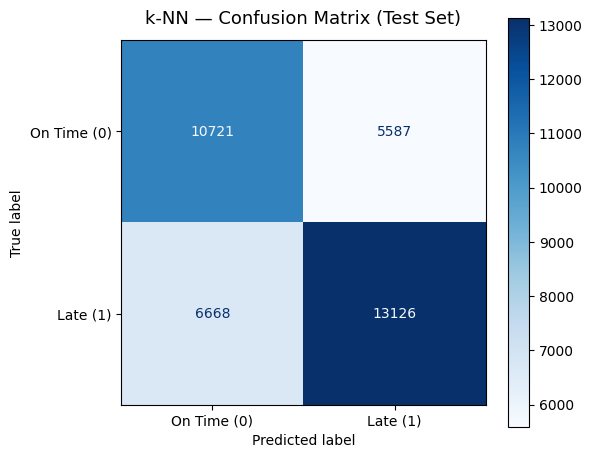

True Negatives  (On-Time correctly classified) : 10,721
False Positives (On-Time predicted as Late)    : 5,587
False Negatives (Late orders missed by model)  : 6,668
True Positives  (Late orders correctly flagged): 13,126


In [6]:
# Step 1: Compute the confusion matrix from test set predictions
cm = confusion_matrix(y_test, y_pred)

# Step 2: Plot the confusion matrix using sklearn's ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['On Time (0)', 'Late (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')

# Step 3: Add title and save the figure to the results folder
ax.set_title('k-NN — Confusion Matrix (Test Set)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'knn_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Step 4: Print raw counts for reference
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (On-Time correctly classified) : {tn:,}")
print(f"False Positives (On-Time predicted as Late)    : {fp:,}")
print(f"False Negatives (Late orders missed by model)  : {fn:,}")
print(f"True Positives  (Late orders correctly flagged): {tp:,}")

- **True Positives (TP):** Late orders correctly flagged — the primary goal for proactive intervention.
- **False Negatives (FN):** Late orders missed — the costliest error; logistics cannot intervene for these.
- **False Positives (FP):** On-time orders wrongly flagged — creates unnecessary work but less harmful.
- **True Negatives (TN):** On-time orders correctly cleared.

Recall = `TP / (TP + FN)` — the fraction of truly late orders caught. This is the business-critical metric.

## Step 7 — k vs. F1 Validation Curve

This plot shows how the best validation F1 score (across all `metric`/`weights` combinations)  
varies with `k`. It is a mandatory figure per `docs.md` §7.3.B (Figure 8).

- Low k → noisy, high-variance boundary (risk of overfitting)
- High k → smooth, high-bias boundary (risk of underfitting)
- The optimal k sits at the peak of this curve

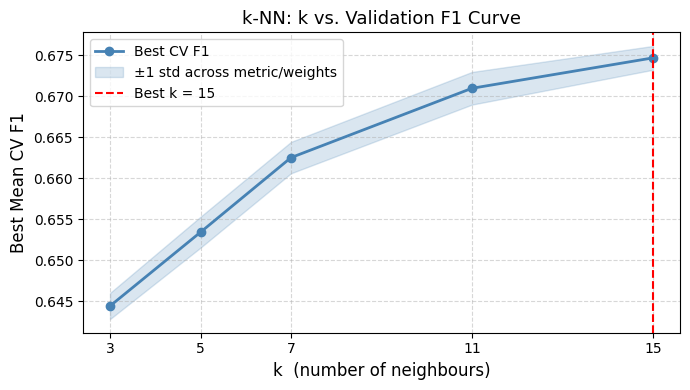

 k  best_cv_f1
 3    0.644408
 5    0.653405
 7    0.662496
11    0.670946
15    0.674652


In [7]:
# Step 1: Load GridSearchCV cv_results_ into a DataFrame
cv_df = pd.DataFrame(grid_search.cv_results_)

# Step 2: For each k, take the best mean CV F1 across all metric/weights combinations
k_f1 = (
    cv_df
    .groupby('param_n_neighbors')['mean_test_score']
    .max()
    .reset_index()
    .rename(columns={'param_n_neighbors': 'k', 'mean_test_score': 'best_cv_f1'})
)

# Step 3: Compute the spread (std) across metric/weights combos for each k as an error band
k_std = (
    cv_df
    .groupby('param_n_neighbors')['mean_test_score']
    .std()
    .reset_index()
    .rename(columns={'param_n_neighbors': 'k', 'mean_test_score': 'std_cv_f1'})
)
k_plot = k_f1.merge(k_std, on='k')

# Step 4: Plot k vs. F1 with an error ribbon
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_plot['k'], k_plot['best_cv_f1'],
        marker='o', linewidth=2, color='steelblue', label='Best CV F1')
ax.fill_between(
    k_plot['k'],
    k_plot['best_cv_f1'] - k_plot['std_cv_f1'],
    k_plot['best_cv_f1'] + k_plot['std_cv_f1'],
    alpha=0.2, color='steelblue', label='±1 std across metric/weights'
)

# Step 5: Mark the best k chosen by GridSearchCV with a vertical red dashed line
best_k = grid_search.best_params_['n_neighbors']
ax.axvline(x=best_k, color='red', linestyle='--',
           linewidth=1.5, label=f'Best k = {best_k}')

ax.set_xlabel('k  (number of neighbours)', fontsize=12)
ax.set_ylabel('Best Mean CV F1', fontsize=12)
ax.set_title('k-NN: k vs. Validation F1 Curve', fontsize=13)
ax.set_xticks(k_plot['k'])
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# Step 6: Save the figure
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'knn_k_vs_f1.png'), dpi=150, bbox_inches='tight')
plt.show()
print(k_plot[['k', 'best_cv_f1']].to_string(index=False))

The curve reveals the bias–variance tradeoff as k increases:  
- If F1 peaks at a small k and then declines, the data has strong local structure that larger  
  neighbourhoods wash out.  
- If F1 keeps rising with k, the dataset benefits from smoother decision boundaries  
  (possibly noisy features that local voting amplifies at small k).  

The red dashed line marks the `best_k` chosen by GridSearchCV — the k that maximises F1  
across all metric/weights combinations on the 5-fold cross-validation.

## Step 8 — 5-Fold Stratified Cross-Validation on the Subsampled Training Set

`StratifiedKFold` provides a robust estimate of generalisation performance by ensuring  
class balance is preserved in every fold (important given the ~55/45 imbalance).  
The CV runs on the **25,000-row subsampled training set** using the best estimator,  
so it reflects expected performance under the same conditions as training.

In [8]:
# Step 1: Define a 5-fold stratified cross-validator with a fixed random seed
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 2: Run cross-validation on the subsampled training set using the best estimator
cv_f1_scores = cross_val_score(
    best_knn, X_train_knn, y_train_knn,
    cv=cv_splitter,
    scoring='f1',
)

# Step 3: Print per-fold scores and summary statistics
print("5-Fold Stratified CV F1 Scores (subsampled training set):")
for i, score in enumerate(cv_f1_scores, start=1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean ± Std : {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}")
print(f"  Min / Max  : {cv_f1_scores.min():.4f} / {cv_f1_scores.max():.4f}")

5-Fold Stratified CV F1 Scores (subsampled training set):
  Fold 1: 0.6879
  Fold 2: 0.6693
  Fold 3: 0.6669
  Fold 4: 0.6737
  Fold 5: 0.6814

  Mean ± Std : 0.6758 ± 0.0078
  Min / Max  : 0.6669 / 0.6879


The mean CV F1 ± std gives the expected test performance and its stability across folds.  
- **Low std (< 0.01):** the model is consistent — confidence in reported test metrics is high.  
- **High std:** the model is sensitive to which 80 % of the subsample it trains on —  
  a concern for deployment reliability.  

Compare the mean CV F1 to `test_f1` from Step 5: if they are close, the evaluation is internally consistent.

## Lecture 4 Connection — Nearest-Neighbor Classification

### Concept

k-NN is the **nearest-neighbor classification** algorithm introduced directly in Lecture 4.  
It is a *non-parametric*, *instance-based* learner: there is no explicit training phase —  
the model stores the entire training set and classifies new points at query time by  
finding the k closest stored examples and taking a majority vote.

---

### Mathematical Formulation

**1. Euclidean Distance** (the primary metric used here):

$$d(\mathbf{x},\, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{d}(x_j - x_{ij})^2}$$

where $\mathbf{x}$ is the query point, $\mathbf{x}_i$ is a stored training point, and $d = 232$ features.

**2. Majority-Vote Prediction**:

Given the k nearest neighbours $\mathcal{N}_k(\mathbf{x})$:

$$\hat{y} = \arg\max_{c \in \{0,1\}} \sum_{\mathbf{x}_i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y_i = c]$$

When `weights='distance'`, each vote is weighted by $1/d(\mathbf{x}, \mathbf{x}_i)$,  
giving closer neighbours proportionally more influence.

---

### Hyperparameter Mapping

| sklearn param | Lecture 4 concept | Effect |
|:-------------|:------------------|:-------|
| `n_neighbors` (k) | The k in nearest-neighbor classification | Controls boundary complexity: low k = fine-grained (overfitting risk); high k = smooth (underfitting risk) |
| `metric` | The distance function $d(\cdot,\cdot)$ | Euclidean (L2) vs. Manhattan (L1) — different notions of closeness |
| `weights` | Voting scheme | Uniform = majority vote; distance = inverse-distance-weighted vote |

---

### Regularisation Note

k-NN does not use an explicit regularisation term.  
Instead, **k itself acts as the implicit regulariser**: increasing k smooths the decision boundary  
and reduces model complexity — conceptually equivalent to increasing $\lambda$ in  
Lecture 4's regularisation framework:

$$\text{cost}(h) = \text{loss}(h) + \lambda \cdot \text{complexity}(h)$$

Large k = large effective $\lambda$ = simpler, more regularised hypothesis.

## Step 9 — Save Results to `knn_results.pkl`

Save all model artefacts using the **exact schema required by `PHASES.md` §2.3**.  
Phase 6 (merge notebook) depends on these keys being present with the correct names  
and types — any deviation will cause the schema validator in Phase 6 to fail.

In [9]:
# Step 1: Build the results dictionary following the PHASES.md §2.3 schema exactly
results = {
    'model_name':         'k-NN',
    'model':              best_knn,
    'best_params':        grid_search.best_params_,
    'y_pred':             y_pred,
    'y_proba':            y_proba,
    'metrics':            metrics,
    'cv_f1_scores':       cv_f1_scores,
    'train_f1':           train_f1,
    'test_f1':            test_f1,
    'feature_importance': None,   # k-NN does not produce feature importances
}

# Step 2: Assert all required top-level keys are present (Phase 6 schema validator)
required_keys = {
    'model_name', 'model', 'best_params', 'y_pred', 'y_proba',
    'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance',
}
assert set(results.keys()) == required_keys, \
    f"Schema mismatch — missing: {required_keys - set(results.keys())}"

# Step 3: Assert the 'metrics' sub-dict has all five required metric keys
required_metric_keys = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
assert set(results['metrics'].keys()) == required_metric_keys, \
    f"Metrics mismatch — missing: {required_metric_keys - set(results['metrics'].keys())}"

# Step 4: Save to results/knn_results.pkl
output_path = RESULTS_DIR / 'knn_results.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(results, f)

print(f"Saved   : {output_path}")
print(f"Keys    : {list(results.keys())}")
print("Metrics :")
for k, v in results['metrics'].items():
    print(f"  {k:<12}: {v:.4f}")

Saved   : ../results/knn_results.pkl
Keys    : ['model_name', 'model', 'best_params', 'y_pred', 'y_proba', 'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance']
Metrics :
  accuracy    : 0.6605
  precision   : 0.7014
  recall      : 0.6631
  f1          : 0.6817
  roc_auc     : 0.7158


### Phase 1 Complete ✓

`results/knn_results.pkl` has been saved with the full PHASES.md §2.3 schema.  
This file is ready to be downloaded from Google Drive and picked up by Phase 6.

**Figures saved:**
- `results/knn_confusion_matrix.png`
- `results/knn_k_vs_f1.png`

**Schema keys confirmed:** `model_name`, `model`, `best_params`, `y_pred`, `y_proba`,  
`metrics` (accuracy / precision / recall / f1 / roc_auc), `cv_f1_scores`, `train_f1`, `test_f1`, `feature_importance`.